# Painel de Análise de Vendas com Visualização de Dados
**Arquivo:** painel_vendas.ipynb  
**Bibliotecas:** pandas, numpy, matplotlib e seaborn

## Etapa 1 — Preparação e Importação de Dados

### 1) Importando as bibliotecas

In [1]:
# Importa as bibliotecas que vamos usar no projeto
import os                          # para criar a pasta dos gráficos
import pandas as pd                # manipulação de tabelas (DataFrames)
import numpy as np                 # cálculos numéricos
import matplotlib.pyplot as plt    # gráficos
import seaborn as sns              # gráficos mais bonitos e estatísticos

# Cria a pasta 'graficos' (se ainda não existir) para salvar as imagens
os.makedirs('graficos', exist_ok=True)

### 2) Carregando o arquivo `vendas.csv` e convertendo a coluna `data` para datetime

In [2]:
# Lê o arquivo CSV (ele precisa estar na mesma pasta do notebook)
df = pd.read_csv('vendas.csv')

# Converte a coluna 'data' de texto para o tipo datetime
df['data'] = pd.to_datetime(df['data'])

# Mostra as 5 primeiras linhas para conferir
df.head()

,data,loja,regiao,produto,categoria,quantidade,preco_unitario
0,2024-01-02,Loja Shopping,Sudeste,Fone de Ouvido,Acessórios,7.0,147.93
1,2024-01-03,Loja Shopping,Sudeste,Webcam,Acessórios,2.0,213.57
2,2024-01-04,Loja Nordeste,Nordeste,Fone de Ouvido,Acessórios,8.0,157.67
3,2024-01-08,Loja Sul,Sul,Smartphone,Eletrônicos,6.0,1690.38
4,2024-01-08,Loja Shopping,Sudeste,Webcam,Acessórios,4.0,195.56


### 3) Criando a coluna `faturamento` (quantidade * preco_unitario)

In [3]:
# Faturamento = quantidade vendida x preço de cada unidade
df['faturamento'] = df['quantidade'] * df['preco_unitario']
df.head()

,data,loja,regiao,produto,categoria,quantidade,preco_unitario,faturamento
0,2024-01-02,Loja Shopping,Sudeste,Fone de Ouvido,Acessórios,7.0,147.93,1035.51
1,2024-01-03,Loja Shopping,Sudeste,Webcam,Acessórios,2.0,213.57,427.14
2,2024-01-04,Loja Nordeste,Nordeste,Fone de Ouvido,Acessórios,8.0,157.67,1261.36
3,2024-01-08,Loja Sul,Sul,Smartphone,Eletrônicos,6.0,1690.38,10142.28
4,2024-01-08,Loja Shopping,Sudeste,Webcam,Acessórios,4.0,195.56,782.24


### 4) Verificando a integridade do dataset

In [4]:
# .info() mostra os tipos de dados e quantos valores não nulos existem
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   data            400 non-null    datetime64[us]
 1   loja            400 non-null    str           
 2   regiao          400 non-null    str           
 3   produto         400 non-null    str           
 4   categoria       400 non-null    str           
 5   quantidade      394 non-null    float64       
 6   preco_unitario  394 non-null    float64       
 7   faturamento     388 non-null    float64       
dtypes: datetime64[us](1), float64(3), str(4)
memory usage: 25.1 KB


In [5]:
# .isnull().sum() conta quantos valores ausentes existem em cada coluna
df.isnull().sum()

data               0
loja               0
regiao             0
produto            0
categoria          0
quantidade         6
preco_unitario     6
faturamento       12
dtype: int64

In [6]:
# .describe() mostra o resumo estatístico (média, mínimo, máximo, etc.)
df.describe()

,data,quantidade,preco_unitario,faturamento
count,400,394.000000,394.000000,388.000000
mean,2024-06-30 07:04:48,5.380711,921.738553,4964.023737
min,2024-01-02 00:00:00,1.000000,63.060000,64.130000
25%,2024-04-06 00:00:00,3.000000,149.332500,761.362500
50%,2024-06-27 12:00:00,5.000000,642.855000,1861.305000
75%,2024-09-29 06:00:00,8.000000,1459.482500,7001.740000
max,2024-12-30 00:00:00,10.000000,3504.720000,34309.100000
std,NaN,2.905156,948.536417,6391.368050


### 5) Tratando valores nulos (substituindo pela média da coluna)

In [7]:
# Substitui os valores ausentes de preço e quantidade pela média da própria coluna
df['preco_unitario'] = df['preco_unitario'].fillna(df['preco_unitario'].mean())
df['quantidade'] = df['quantidade'].fillna(df['quantidade'].mean())

# Como os nulos foram preenchidos, recalculamos o faturamento para não ficar nenhum NaN
df['faturamento'] = df['quantidade'] * df['preco_unitario']

# Confere se ainda existem nulos (o resultado deve ser 0 em todas as colunas)
df.isnull().sum()

data              0
loja              0
regiao            0
produto           0
categoria         0
quantidade        0
preco_unitario    0
faturamento       0
dtype: int64

## Etapa 2 — Análise Exploratória e Estatísticas

### 6) Total de faturamento por loja (do maior para o menor)

In [8]:
# Agrupa por loja, soma o faturamento e ordena do maior para o menor
fat_loja = df.groupby('loja')['faturamento'].sum().sort_values(ascending=False)
fat_loja

loja
Loja Centro      517295.337081
Loja Shopping    437628.701294
Loja Sul         428091.685660
Loja Norte       398796.476904
Loja Nordeste    210562.272843
Name: faturamento, dtype: float64

### 7) Ticket médio de cada loja (faturamento ÷ número de vendas)

In [9]:
# Soma do faturamento de cada loja
faturamento_loja = df.groupby('loja')['faturamento'].sum()

# Número de vendas (quantidade de linhas) de cada loja
num_vendas = df.groupby('loja')['faturamento'].count()

# Ticket médio = faturamento dividido pelo número de vendas
ticket_medio = (faturamento_loja / num_vendas).sort_values(ascending=False)
ticket_medio

loja
Loja Norte       6135.330414
Loja Sul         5220.630313
Loja Shopping    4756.833710
Loja Centro      4577.834841
Loja Nordeste    4386.714018
Name: faturamento, dtype: float64

### 8) Cinco produtos mais vendidos em quantidade

In [10]:
# Soma a quantidade de cada produto e pega os 5 maiores
top5_produtos = df.groupby('produto')['quantidade'].sum().sort_values(ascending=False).head(5)
top5_produtos

produto
Fone de Ouvido        273.380711
Tablet                253.380711
Mesa de Escritório    232.000000
Teclado               227.000000
Notebook              224.380711
Name: quantidade, dtype: float64

### 9) Mês de maior e menor faturamento (formato Mês/Ano)

In [11]:
# Cria uma coluna com o período no formato Mês/Ano (ex.: 03/2024)
df['mes_ano'] = df['data'].dt.strftime('%m/%Y')

# Soma o faturamento de cada mês/ano
fat_mensal = df.groupby('mes_ano')['faturamento'].sum()

# idxmax() e idxmin() devolvem o nome do mês com maior e menor valor
mes_maior = fat_mensal.idxmax()
mes_menor = fat_mensal.idxmin()

print(f'Mês com MAIOR faturamento: {mes_maior} -> R$ {fat_mensal.max():,.2f}')
print(f'Mês com MENOR faturamento: {mes_menor} -> R$ {fat_mensal.min():,.2f}')

Mês com MAIOR faturamento: 10/2024 -> R$ 226,119.48
Mês com MENOR faturamento: 05/2024 -> R$ 115,774.88


### 10) Adicionando a coluna `mes` extraída da data

In [12]:
# Extrai o número do mês (1 a 12) da coluna data
df['mes'] = df['data'].dt.month
df[['data', 'mes', 'mes_ano']].head()

,data,mes,mes_ano
0,2024-01-02,1,01/2024
1,2024-01-03,1,01/2024
2,2024-01-04,1,01/2024
3,2024-01-08,1,01/2024
4,2024-01-08,1,01/2024


## Etapa 4 (parte 1) — Tema global
> O passo 17 é executado aqui, antes dos gráficos, para que o estilo seja aplicado a **todos** os gráficos seguintes.

### 17) Personalização de tema global

In [13]:
# Define o estilo padrão de todos os gráficos
sns.set_style('whitegrid')

# Define a paleta de cores padrão
sns.set_palette(sns.color_palette('deep'))

## Etapa 3 — Visualizações com matplotlib e seaborn

### 11) Gráfico de barras — Faturamento por loja

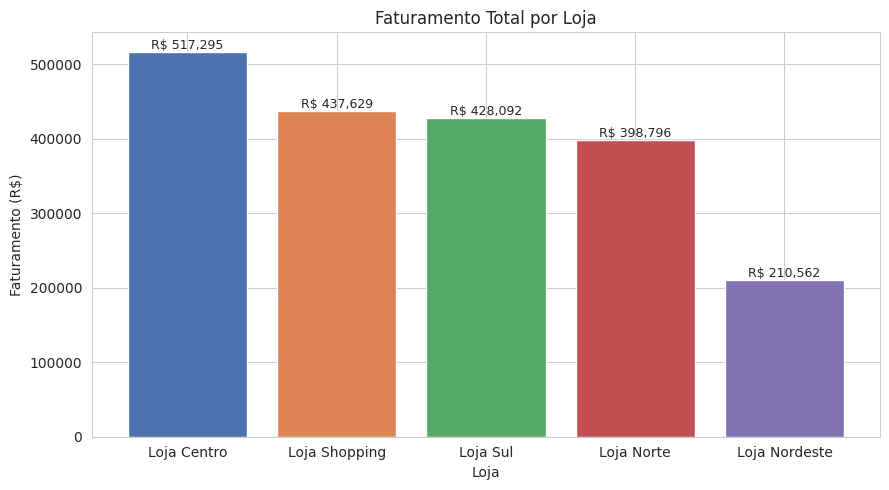

In [14]:
# Dados já calculados no passo 6 (ordenados do maior para o menor)
plt.figure(figsize=(9, 5))
barras = plt.bar(fat_loja.index, fat_loja.values, color=sns.color_palette('deep')[:len(fat_loja)])

# Escreve o valor em cima de cada barra
for barra in barras:
    plt.text(barra.get_x() + barra.get_width() / 2, barra.get_height(),
             f'R$ {barra.get_height():,.0f}', ha='center', va='bottom', fontsize=9)

plt.title('Faturamento Total por Loja')
plt.xlabel('Loja')
plt.ylabel('Faturamento (R$)')
plt.tight_layout()

# Salva o gráfico (na pasta graficos e também na raiz, como o enunciado pede)
plt.savefig('graficos/faturamento_por_loja.png', dpi=150)
plt.savefig('faturamento_por_loja.png', dpi=150)
plt.show()

### 12) Gráfico de linhas — Evolução mensal do faturamento

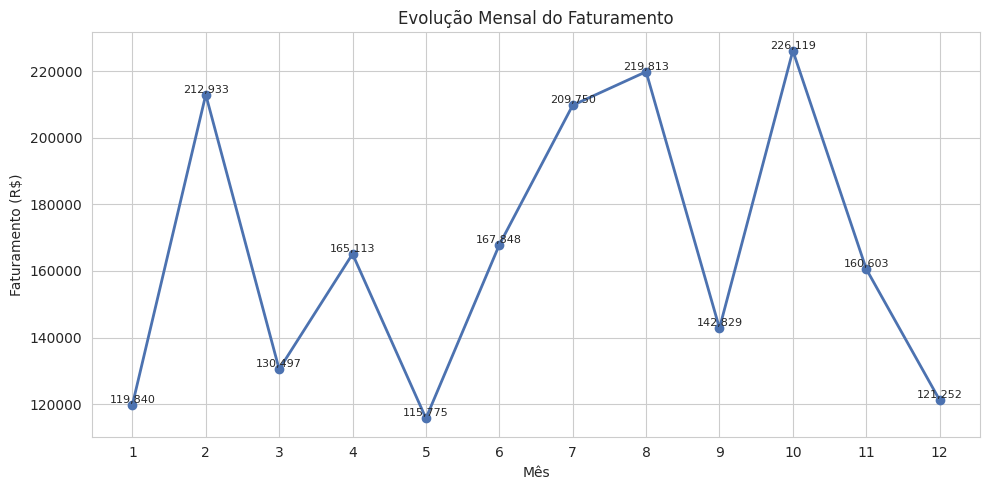

In [15]:
# Resumo mensal ordenado pelo número do mês
fat_mes = df.groupby('mes')['faturamento'].sum()

plt.figure(figsize=(10, 5))
plt.plot(fat_mes.index, fat_mes.values, marker='o', linewidth=2)

# Rótulo (valor) em cada ponto
for x, y in zip(fat_mes.index, fat_mes.values):
    plt.text(x, y, f'{y:,.0f}', ha='center', va='bottom', fontsize=8)

plt.xticks(range(1, 13))
plt.title('Evolução Mensal do Faturamento')
plt.xlabel('Mês')
plt.ylabel('Faturamento (R$)')
plt.tight_layout()
plt.savefig('graficos/evolucao_mensal.png', dpi=150)
plt.show()

### 13) Gráfico de pizza — Distribuição de faturamento por região

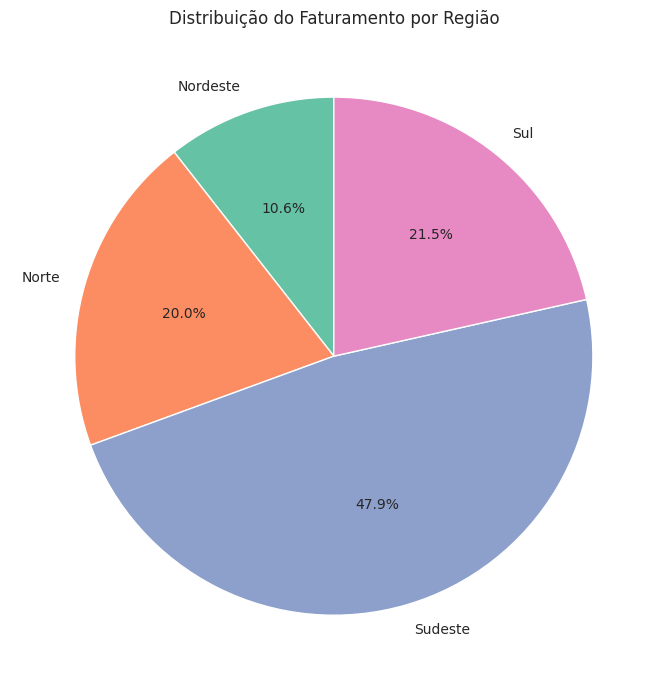

In [16]:
# Soma o faturamento de cada região
fat_regiao = df.groupby('regiao')['faturamento'].sum()

plt.figure(figsize=(7, 7))
plt.pie(fat_regiao.values,
        labels=fat_regiao.index,
        autopct='%1.1f%%',                         # mostra a porcentagem em cada fatia
        colors=sns.color_palette('Set2', len(fat_regiao)),  # cores distintas
        startangle=90)
plt.title('Distribuição do Faturamento por Região')
plt.tight_layout()
plt.savefig('graficos/faturamento_por_regiao.png', dpi=150)
plt.show()

### 14) Gráfico de dispersão — Quantidade x Faturamento

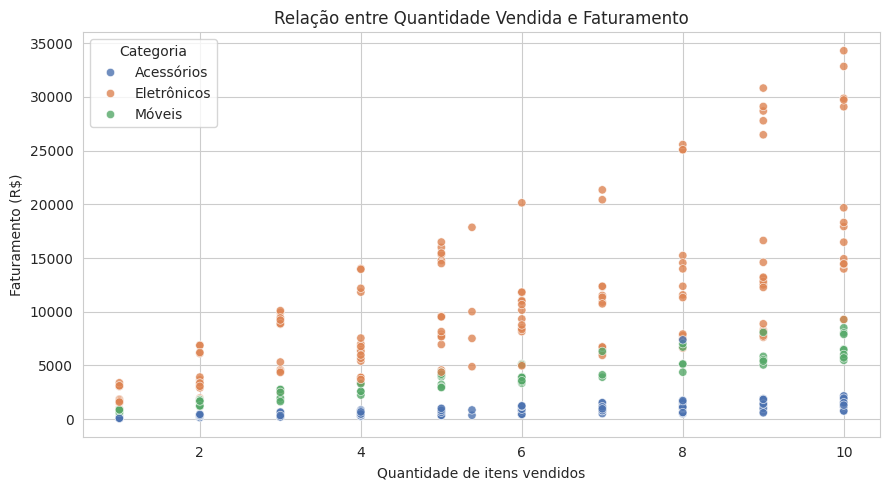

In [17]:
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x='quantidade', y='faturamento', hue='categoria', alpha=0.8)
plt.title('Relação entre Quantidade Vendida e Faturamento')
plt.xlabel('Quantidade de itens vendidos')
plt.ylabel('Faturamento (R$)')
plt.legend(title='Categoria')
plt.tight_layout()
plt.savefig('graficos/dispersao_quantidade_faturamento.png', dpi=150)
plt.show()

### 15) Boxplot — Distribuição de preços por categoria

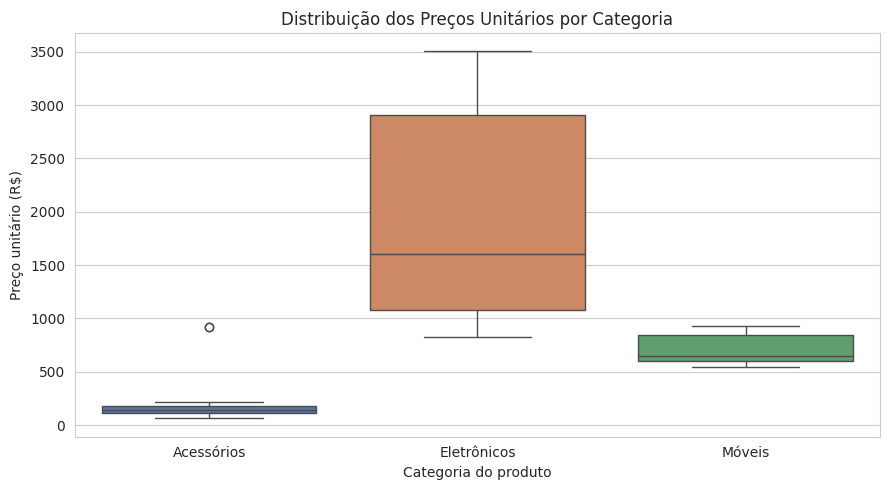

In [18]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='categoria', y='preco_unitario', hue='categoria', legend=False)
plt.title('Distribuição dos Preços Unitários por Categoria')
plt.xlabel('Categoria do produto')
plt.ylabel('Preço unitário (R$)')
plt.tight_layout()
plt.savefig('graficos/boxplot_preco_categoria.png', dpi=150)
plt.show()

### 16) Heatmap — Correlação entre variáveis numéricas

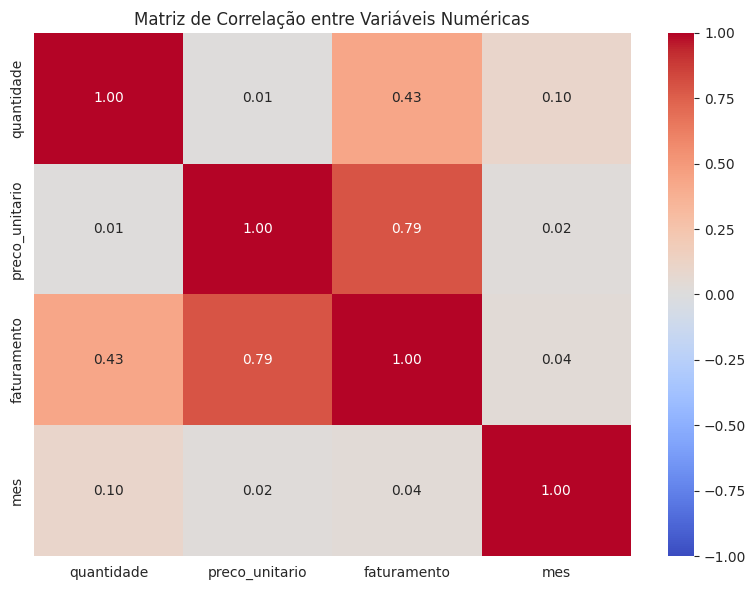

In [19]:
# Seleciona só as colunas numéricas e calcula a matriz de correlação
colunas_numericas = ['quantidade', 'preco_unitario', 'faturamento', 'mes']
correlacao = df[colunas_numericas].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlacao, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matriz de Correlação entre Variáveis Numéricas')
plt.tight_layout()
plt.savefig('graficos/heatmap_correlacao.png', dpi=150)
plt.show()

## Etapa 4 — Estilização e Apresentação (continuação)

### 18) Ajuste de rótulos e títulos
Todos os gráficos acima já possuem **título descritivo**, **rótulos nos eixos** e tamanho de figura adequado para boa leitura, sem textos genéricos como "Gráfico 1".

### 19) Layout com múltiplos gráficos (plt.subplots)

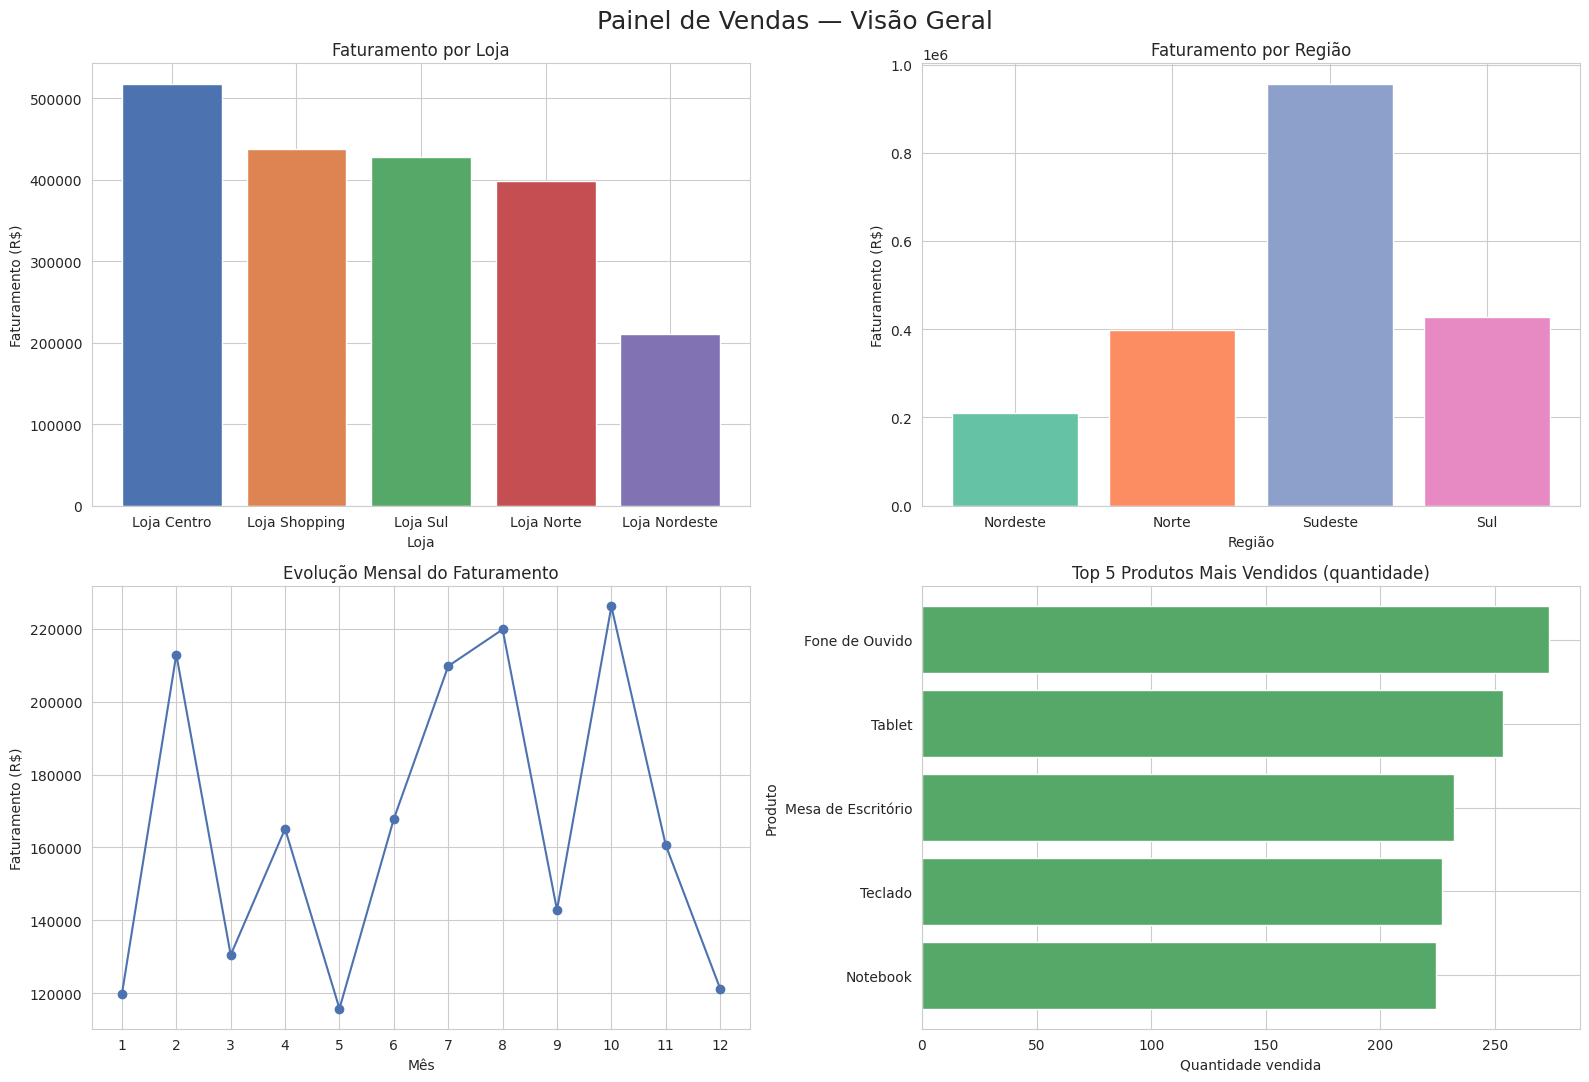

In [20]:
# Cria uma figura com 2 linhas x 2 colunas de gráficos
fig, eixos = plt.subplots(2, 2, figsize=(16, 11))

# Gráfico 1: faturamento por loja
eixos[0, 0].bar(fat_loja.index, fat_loja.values, color=sns.color_palette('deep')[:len(fat_loja)])
eixos[0, 0].set_title('Faturamento por Loja')
eixos[0, 0].set_xlabel('Loja')
eixos[0, 0].set_ylabel('Faturamento (R$)')

# Gráfico 2: faturamento por região
eixos[0, 1].bar(fat_regiao.index, fat_regiao.values, color=sns.color_palette('Set2', len(fat_regiao)))
eixos[0, 1].set_title('Faturamento por Região')
eixos[0, 1].set_xlabel('Região')
eixos[0, 1].set_ylabel('Faturamento (R$)')

# Gráfico 3: evolução mensal
eixos[1, 0].plot(fat_mes.index, fat_mes.values, marker='o')
eixos[1, 0].set_xticks(range(1, 13))
eixos[1, 0].set_title('Evolução Mensal do Faturamento')
eixos[1, 0].set_xlabel('Mês')
eixos[1, 0].set_ylabel('Faturamento (R$)')

# Gráfico 4: top 5 produtos mais vendidos
eixos[1, 1].barh(top5_produtos.index[::-1], top5_produtos.values[::-1], color=sns.color_palette('deep')[2])
eixos[1, 1].set_title('Top 5 Produtos Mais Vendidos (quantidade)')
eixos[1, 1].set_xlabel('Quantidade vendida')
eixos[1, 1].set_ylabel('Produto')

fig.suptitle('Painel de Vendas — Visão Geral', fontsize=18)
plt.tight_layout()
plt.savefig('graficos/painel_geral.png', dpi=150)
plt.show()

### 20) Exportação e relatório final

In [21]:
# Confere todos os gráficos salvos na pasta graficos/
print('Gráficos salvos:')
for arquivo in sorted(os.listdir('graficos')):
    print(' -', arquivo)

Gráficos salvos:
 - boxplot_preco_categoria.png
 - dispersao_quantidade_faturamento.png
 - evolucao_mensal.png
 - faturamento_por_loja.png
 - faturamento_por_regiao.png
 - heatmap_correlacao.png
 - painel_geral.png


In [22]:
# Monta o resumo analítico consolidando os principais resultados
linhas = []

# Faturamento e ticket médio de cada loja
for loja in fat_loja.index:
    linhas.append(['Faturamento por loja', loja, round(fat_loja[loja], 2)])
    linhas.append(['Ticket médio por loja', loja, round(ticket_medio[loja], 2)])

# Faturamento por região
for regiao, valor in fat_regiao.items():
    linhas.append(['Faturamento por região', regiao, round(valor, 2)])

# Top 5 produtos por quantidade
for produto, qtd in top5_produtos.items():
    linhas.append(['Top 5 produtos (quantidade)', produto, int(qtd)])

# Mês de maior e menor faturamento
linhas.append(['Mês de maior faturamento', mes_maior, round(fat_mensal.max(), 2)])
linhas.append(['Mês de menor faturamento', mes_menor, round(fat_mensal.min(), 2)])

resumo = pd.DataFrame(linhas, columns=['indicador', 'item', 'valor'])
resumo.to_csv('resumo_analitico.csv', index=False, encoding='utf-8-sig')
resumo

,indicador,item,valor
0,Faturamento por loja,Loja Centro,517295.34
1,Ticket médio por loja,Loja Centro,4577.83
2,Faturamento por loja,Loja Shopping,437628.70
3,Ticket médio por loja,Loja Shopping,4756.83
4,Faturamento por loja,Loja Sul,428091.69
5,Ticket médio por loja,Loja Sul,5220.63
6,Faturamento por loja,Loja Norte,398796.48
7,Ticket médio por loja,Loja Norte,6135.33
8,Faturamento por loja,Loja Nordeste,210562.27
9,Ticket médio por loja,Loja Nordeste,4386.71


### Comentários finais — o que foi observado nas visualizações

- **Faturamento por loja:** a *Loja Centro* lidera (cerca de R$ 517 mil) e a *Loja Nordeste* tem o menor faturamento (cerca de R$ 211 mil).
- **Ticket médio:** a *Loja Norte* tem o maior ticket médio (≈ R$ 6.135), mesmo sendo a 4ª em faturamento total. Ou seja, vende menos vezes, mas vendas de maior valor.
- **Regiões:** o Sudeste concentra quase metade do faturamento (≈ 47,9%), seguido por Sul (21,5%), Norte (20,0%) e Nordeste (10,6%).
- **Evolução mensal:** o melhor mês foi **10/2024** e o pior foi **05/2024**. Há picos também em fevereiro, julho e agosto, e queda em dezembro.
- **Produtos:** o Fone de Ouvido é o mais vendido em quantidade, seguido de Tablet e Mesa de Escritório.
- **Dispersão:** quanto maior a quantidade vendida, maior tende a ser o faturamento, mas a categoria (preço do produto) muda bastante o resultado.
- **Boxplot:** Eletrônicos têm os preços mais altos e com maior variação. Alguns pontos fora da curva em Acessórios aparecem porque os preços ausentes foram substituídos pela média geral (passo 5), o que pode gerar *outliers*.
- **Heatmap:** o faturamento tem correlação mais forte com o preço unitário (≈ 0,79) do que com a quantidade (≈ 0,43). Quantidade e preço quase não se relacionam (≈ 0,01).